In [4]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)

# looking in depth at p asteroides 
- transect
- changes in alpha diversity of PAST 

In [5]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 470 samples ]
sample_data() Sample Data:       [ 470 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [6]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [7]:
#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46460 taxa and 467 samples ]
sample_data() Sample Data:       [ 467 samples by 9 sample variables ]
tax_table()   Taxonomy Table:    [ 46460 taxa by 6 taxonomic ranks ]

In [8]:
#normalizing ps by converting rawcounts into relative abundances
#so samples with more reads wont be over represented
#using ps bc only to the count data (OTU table), while preserving the rest of the object
ps_norm = transform_sample_counts(ps_prune, function(x) 1E6 * x / sum(x))

## cleaning ps object

In [9]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_norm)$Month_year <- factor(sample_data(ps_norm)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


In [10]:
pssd2veg <- function(ps_norm) {
  sd_nomit <- sample_data(ps_norm)
  return(as(sd_nomit,"data.frame"))
}
#using phyloseq nmds plot no chloroplast
sample_nomit <- pssd2veg(ps_norm)

sample_nomit <- as.data.frame(sample_data(ps_norm))
#save sammple names as a column so tidy doesn't get rid of it during filtering
sample_nomit$SampleID <- rownames(sample_nomit)

### only include repeated colonies

In [11]:
# Return names which have more than one row of data
# Now filter
colonies <- sample_nomit %>%
  group_by(colony) %>%
  filter(n() != 1) %>%
  ungroup()

#difference bw og and repeated colonies df
nrow(sample_nomit)
nrow(colonies)

#how many colonies
length(unique(colonies$colony))

[1] 467

[1] 455

[1] 68

In [12]:
# Restore rownames
rownames(colonies) <- colonies$SampleID
#check
head(rownames(colonies))
nrow(sample_data(ps_norm))
head(colonies)

Warning message:
“Setting row names on a tibble is deprecated.”


[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] 467

Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,SampleID
<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>
Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21,052022_BEL_CBC_T1_2_SSID
Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25,092023_BEL_CBC_T1_175_PAST
Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24,022024_BEL_CBC_T3_851_PSTR
Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22,082024_BEL_CBC_T4_1609_OFAV
Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16,122023_BEL_CBC_T3_526_SSID
Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13,112023_BEL_CBC_T4_399_MCAV


In [13]:
colonies <- as.data.frame(colonies)
class(colonies)

Warning message in class(x) <- tibble_class:
“Setting class(x) to multiple strings ("tbl_df", "tbl", ...); result will no longer be an S4 object”


[1] "data.frame"

In [16]:
# Restore rownames
rownames(colonies) <- colonies$SampleID

## created new ps object with colonies dataframe

In [17]:
keep_samples <- rownames(colonies)
length(keep_samples)
#how many of the values in keep_samples exist in ps_norm
sum(keep_samples %in% sample_names(ps_norm))  # Should be 455

[1] 455

[1] 455

In [19]:
# check they are the same rownames
head(sample_names(ps_norm))
head(keep_samples)

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

[1] "052022_BEL_CBC_T1_2_SSID"    "092023_BEL_CBC_T1_175_PAST" 
[3] "022024_BEL_CBC_T3_851_PSTR"  "082024_BEL_CBC_T4_1609_OFAV"
[5] "122023_BEL_CBC_T3_526_SSID"  "112023_BEL_CBC_T4_399_MCAV"

In [20]:
# Prune to keep only those samples
ps_col <- prune_samples(sample_names(ps_norm) %in% keep_samples, ps_norm)
     

In [21]:
## check up on ps_col
class(ps_col)
nrow(sample_data(ps_col))

all(rownames(colonies) %in% sample_names(ps_col))
head(sample_data(ps_col))

[1] "phyloseq"
attr(,"package")
[1] "phyloseq"

[1] 455

[1] TRUE

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>
052022_BEL_CBC_T1_2_SSID,Diseased_Tissue,1_3,1_22_2025,Diseased,SSID,May 2022,1,CBC30N,2022-05-21
092023_BEL_CBC_T1_175_PAST,Healthy,1_13,1_22_2025,Healthy,PAST,Sep 2023,1,CBC30N,2023-09-25
022024_BEL_CBC_T3_851_PSTR,Healthy,3_70,1_23_2025,Healthy,PSTR,Feb 2024,1,Lagoon,2024-02-24
082024_BEL_CBC_T4_1609_OFAV,Healthy,4_78,1_23_2025,Healthy,OFAV,Aug 2024,1,Curlew,2024-08-22
122023_BEL_CBC_T3_526_SSID,Healthy,3_5,1_23_2025,Healthy,SSID,Dec 2023,1,Lagoon,2023-12-16
112023_BEL_CBC_T4_399_MCAV,Bleached_Tissue,4_76,1_23_2025,CLP,MCAV,Nov 2023,1,Curlew,2023-11-13


In [22]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_col)$Month_year <- factor(sample_data(ps_col)$Month_year,levels = c("Jun 2019","May 2022","Oct 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))


## isolate samples that are PAST

In [23]:
ps_past <- subset_samples(ps_col, Species == "PAST") 
nrow(sample_data(ps_past))#96

[1] 96

## taxonomy plots 
- how many bacterial communities should I let through? top 50? 100?
- what level should I show? order, Family, Genus?

In [24]:
# plot sizing
options(repr.plot.width=20, repr.plot.height=15)

In [25]:

    # how many unique family taxa are there total?
length(unique(tax_table(ps_col)[, "Family"]))

    # how many unique family taxa are there in PAST?
length(unique(tax_table(ps_past)[, "Family"]))

[1] 469

[1] 469

In [26]:
#reduce that to top 50
ps_past=tax_glom(ps_past, taxrank= "Family")

top50_past <- names(sort(taxa_sums(ps_past), decreasing=TRUE))[1:50] 
top50_past <- prune_taxa(top50_past, ps_past) 


In [27]:
## assigning colors 

#assigning colors
famcolors= colorRampPalette(brewer.pal(8, "Accent"))(50)

#Generate a random set of colors based on a df fam_taxa that assigns a random color to each spot in the list
fam_taxa <- unique(tax_table(top50_past)[, "Family"])
    famcolors <- sample(famcolors, 50, length(fam_taxa))
    # naming my color palette so the random order stays the same
    famcolors<- setNames(famcolors, fam_taxa)

### family taxonomy abundances over time
- facetted by colony

# look for endozoicomonas bleaching papers 

Warning message in geom_text(aes(label = Family, fill = Family), position = position_stack(vjust = 0.5), :
“Ignoring unknown aesthetics: fill”


<Guides[1] ggproto object>

colour : <GuideLegend>

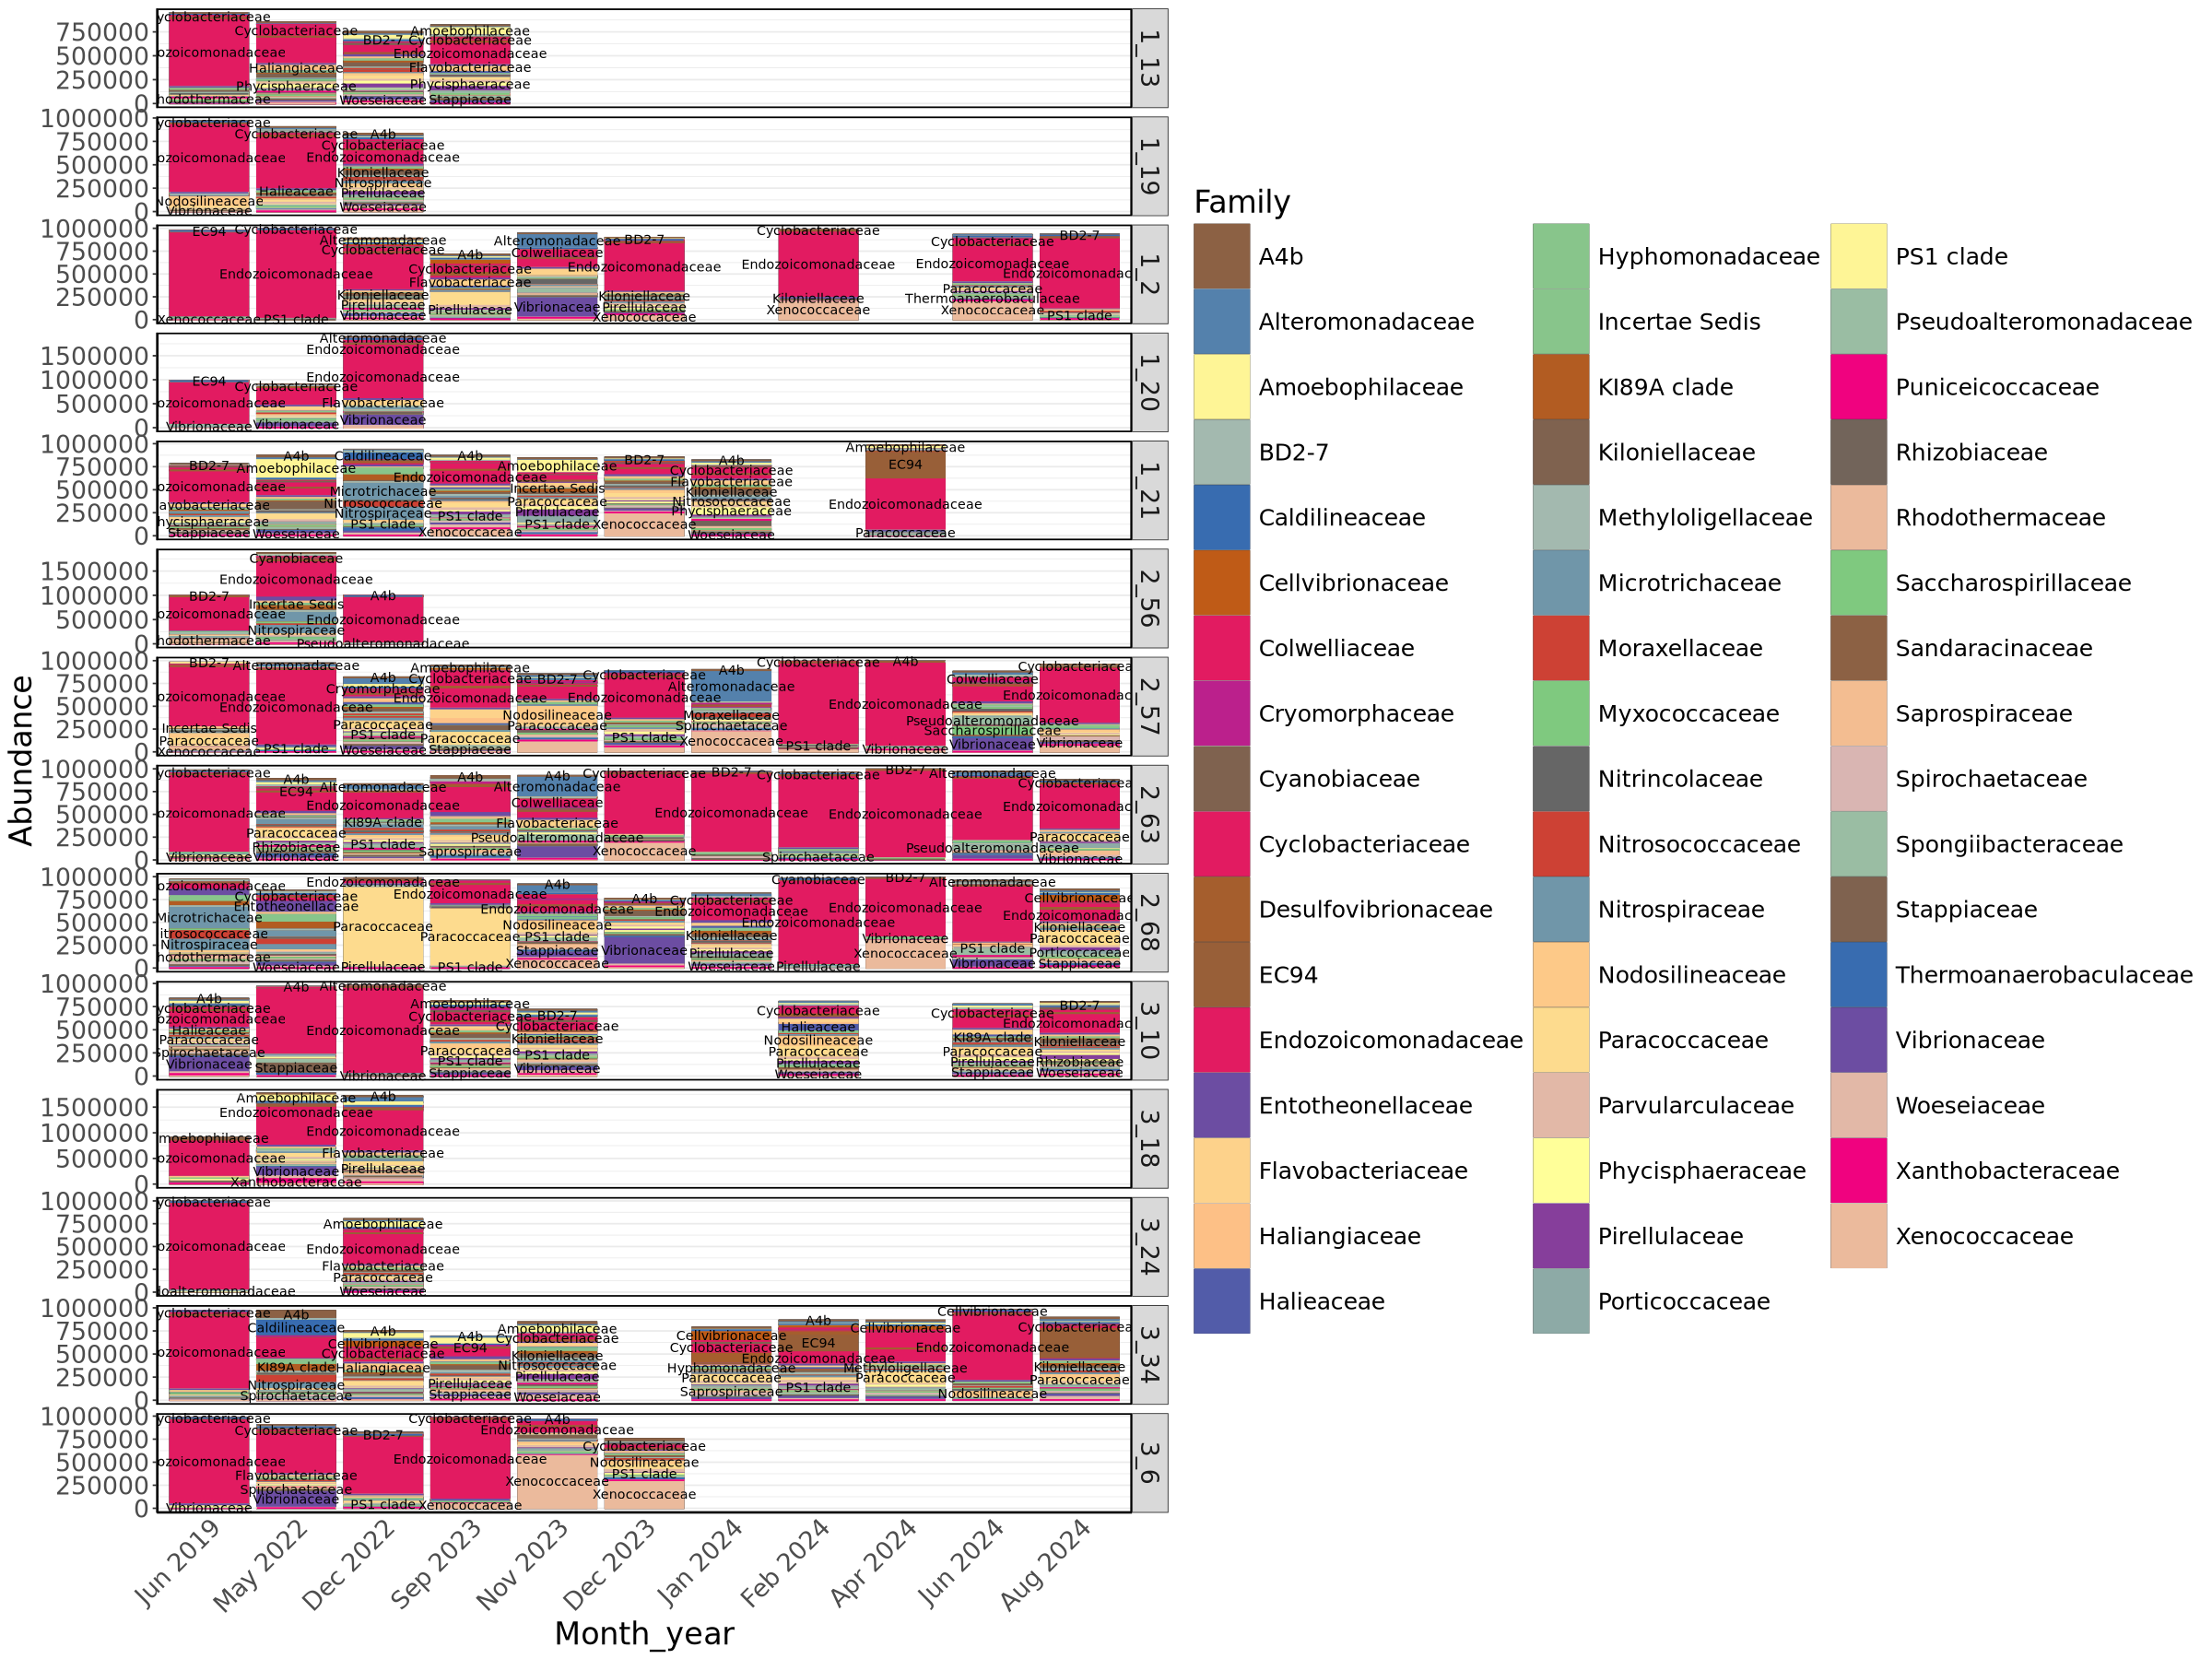

In [34]:

#plot
past <- plot_bar(top50_past, x="Month_year", fill = "Family") +
  facet_wrap(colony ~., strip.position = "right", ncol = 1, scales = "free_y") +
  geom_bar(aes(color = Family, fill = Family), 
           stat = "identity", position = "stack") +
  geom_text(aes(label = Family, fill = Family),
            position = position_stack(vjust = 0.5),
            color = "black", size = 3, check_overlap = TRUE) +
  scale_fill_manual(values = famcolors, drop = TRUE) +
  scale_color_manual(values = famcolors, drop = TRUE) +
  theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1),
    text = element_text(size = 20)
  )
guides(color = guide_legend(override.aes = list(size = 6))) 
past

In [ ]:
### family taxonomy abundances over time 

## alpha diversity
- null hypothesis: microbiome diversity in coral colonies has changed over time
- null hypothesis: not all transects have equal diversity  

### using phylsoeq to see alpha diversity changes
- use un-pruned ps object

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


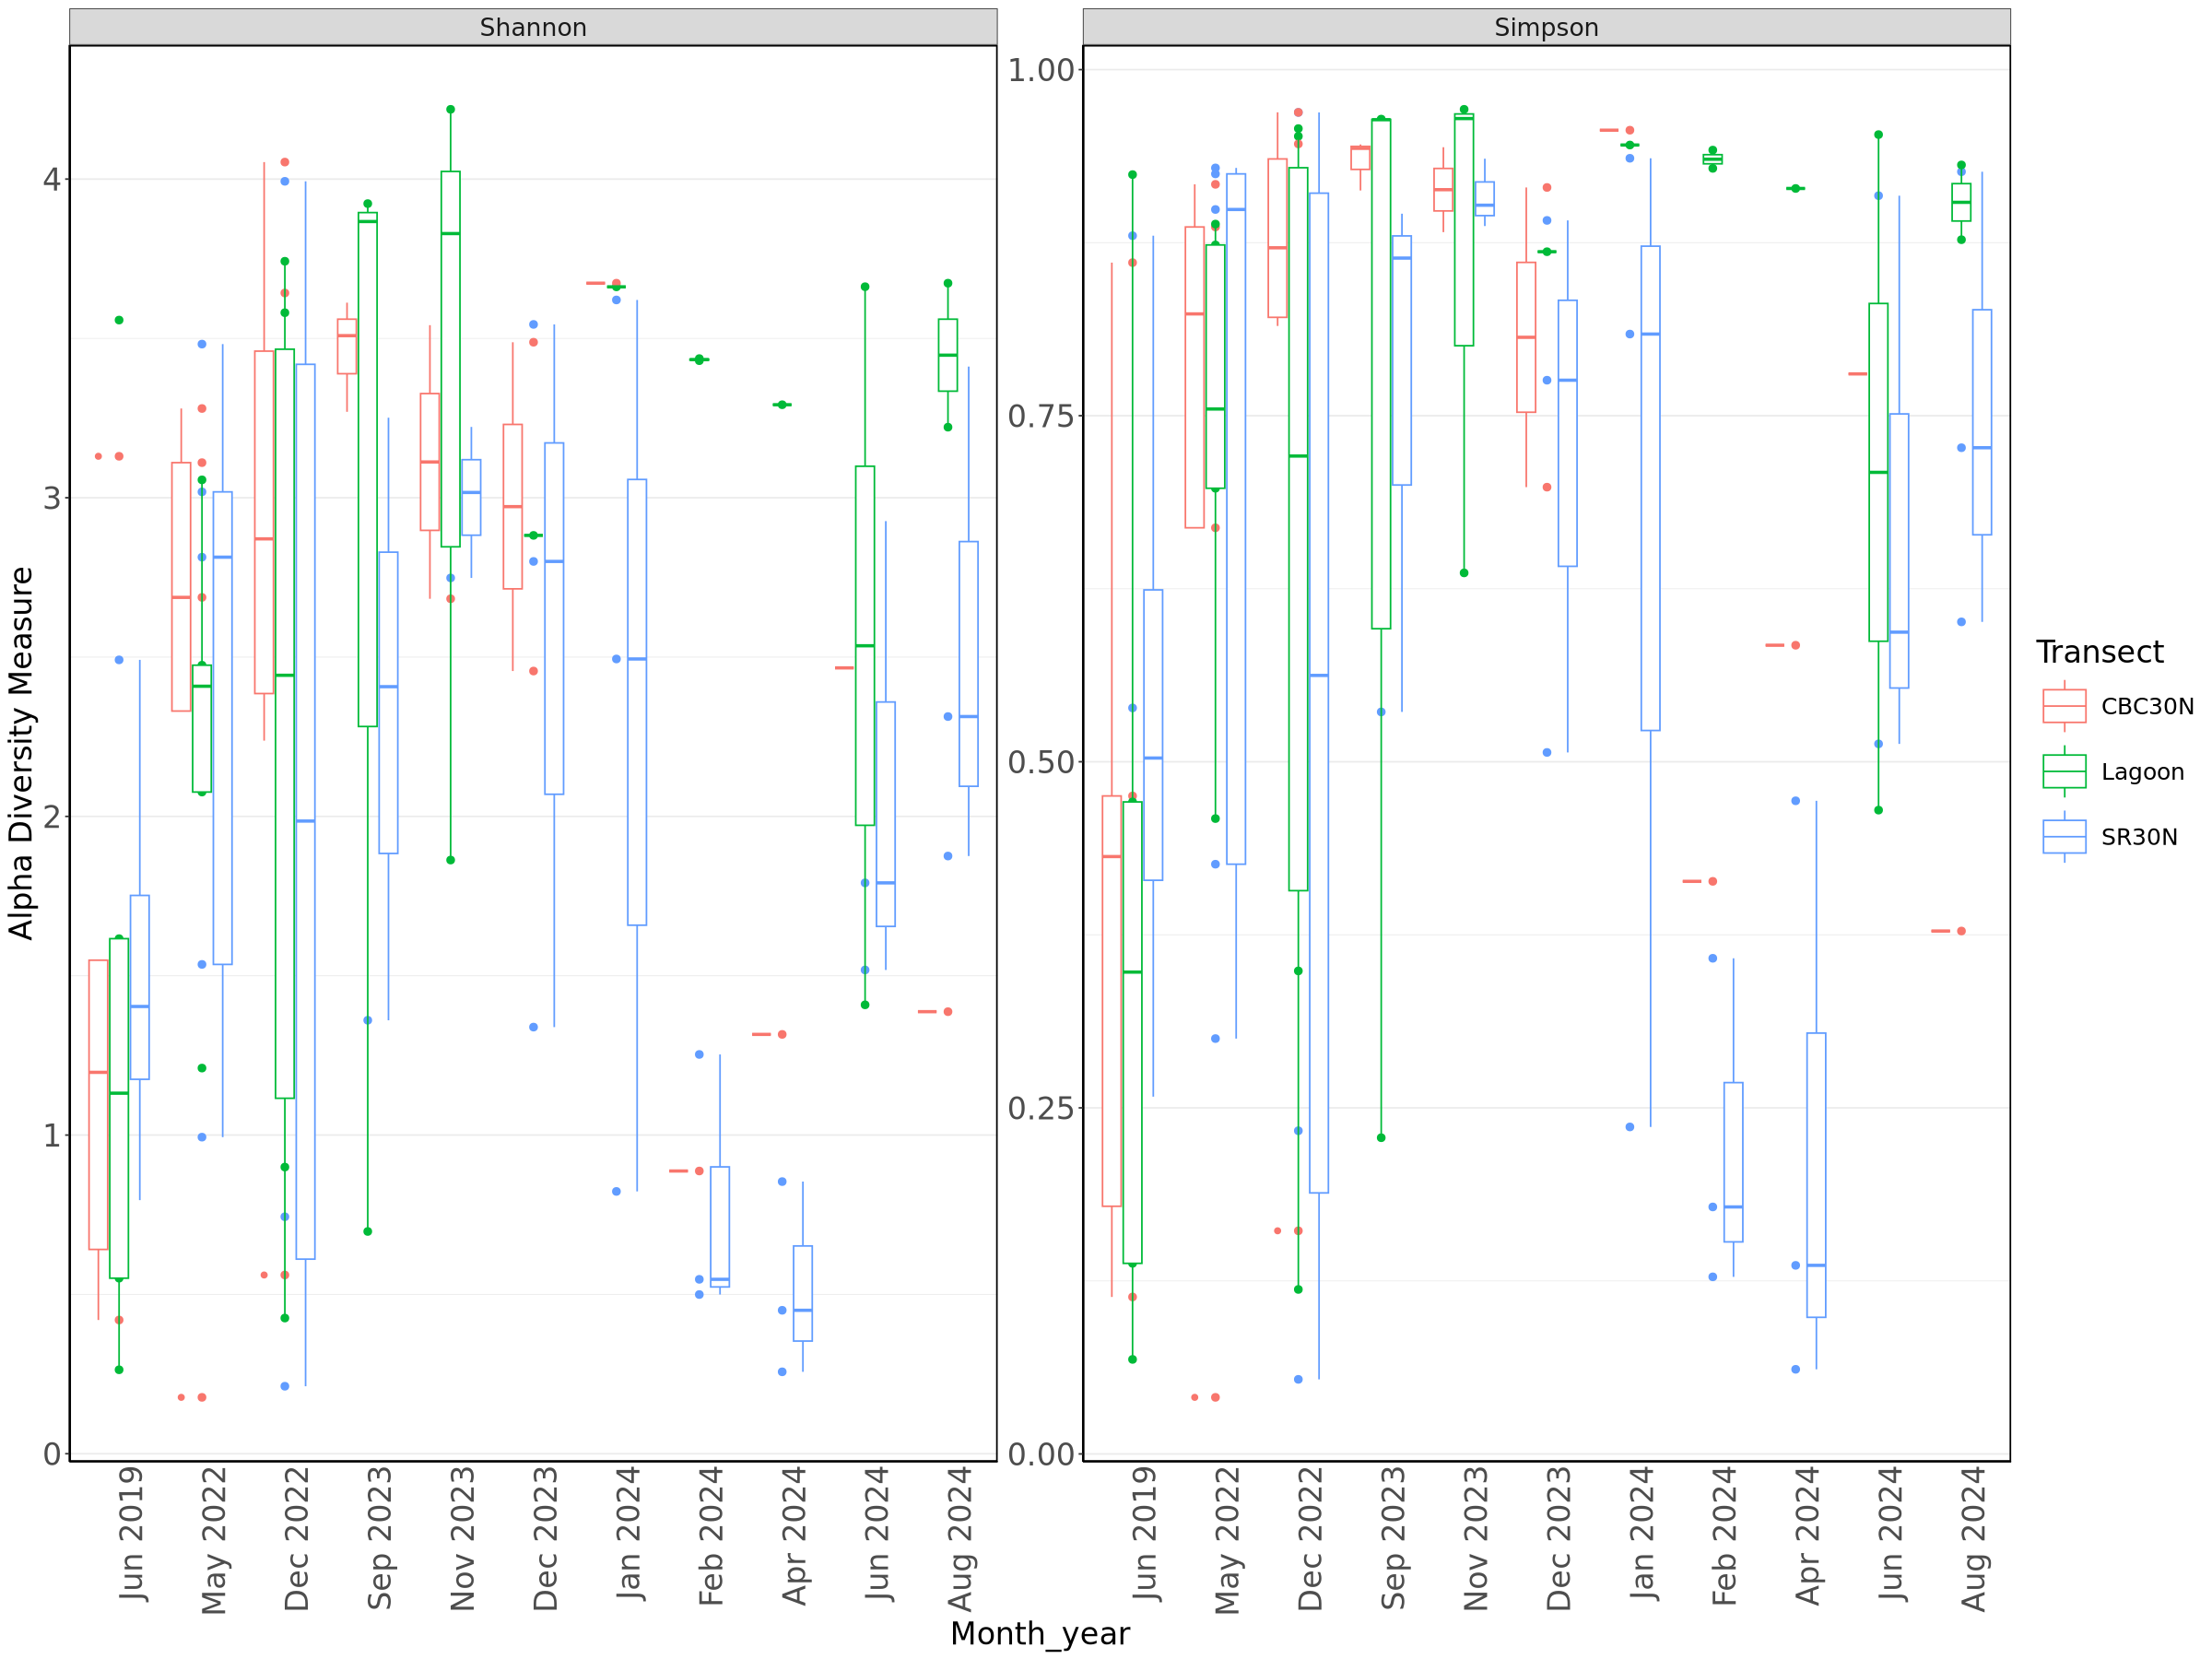

In [33]:
# box plots

plot_richness(ps_past, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
geom_point(size=2) +
geom_boxplot() +
theme_bw() +
  theme(
    legend.position = "right",
      legend.title = element_text(size = 20),
  legend.text = element_text(size = 15),
  legend.key.width = unit(1.3, "cm"),     # make the legend keys wider
  legend.key.height = unit(1.5, "cm"),   # make them taller
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### figure notes
- the above figure shows how alpha diversity shifts in P. asteroides (on different scales depending on Shannon or simpson calculations)
- We can see some shifts in alpha diversity overtime. For example we see that PAST colonies in all 3 reefs showed higher bacterial community diversity during the 2023 bleaching event (peak dievrsity in Nov 2023)
- After Nov 2023, diversity in SR30N and CBC30N began recovering in June 2024. In contrast PAST colonies at Lagoon experienced a boom in bacterial community diversity after bleaching 2023.

In [35]:
## but could the increased diversity be due to the fact that only 3/5 colonies from lagoon were sampled during NSF rapid?

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


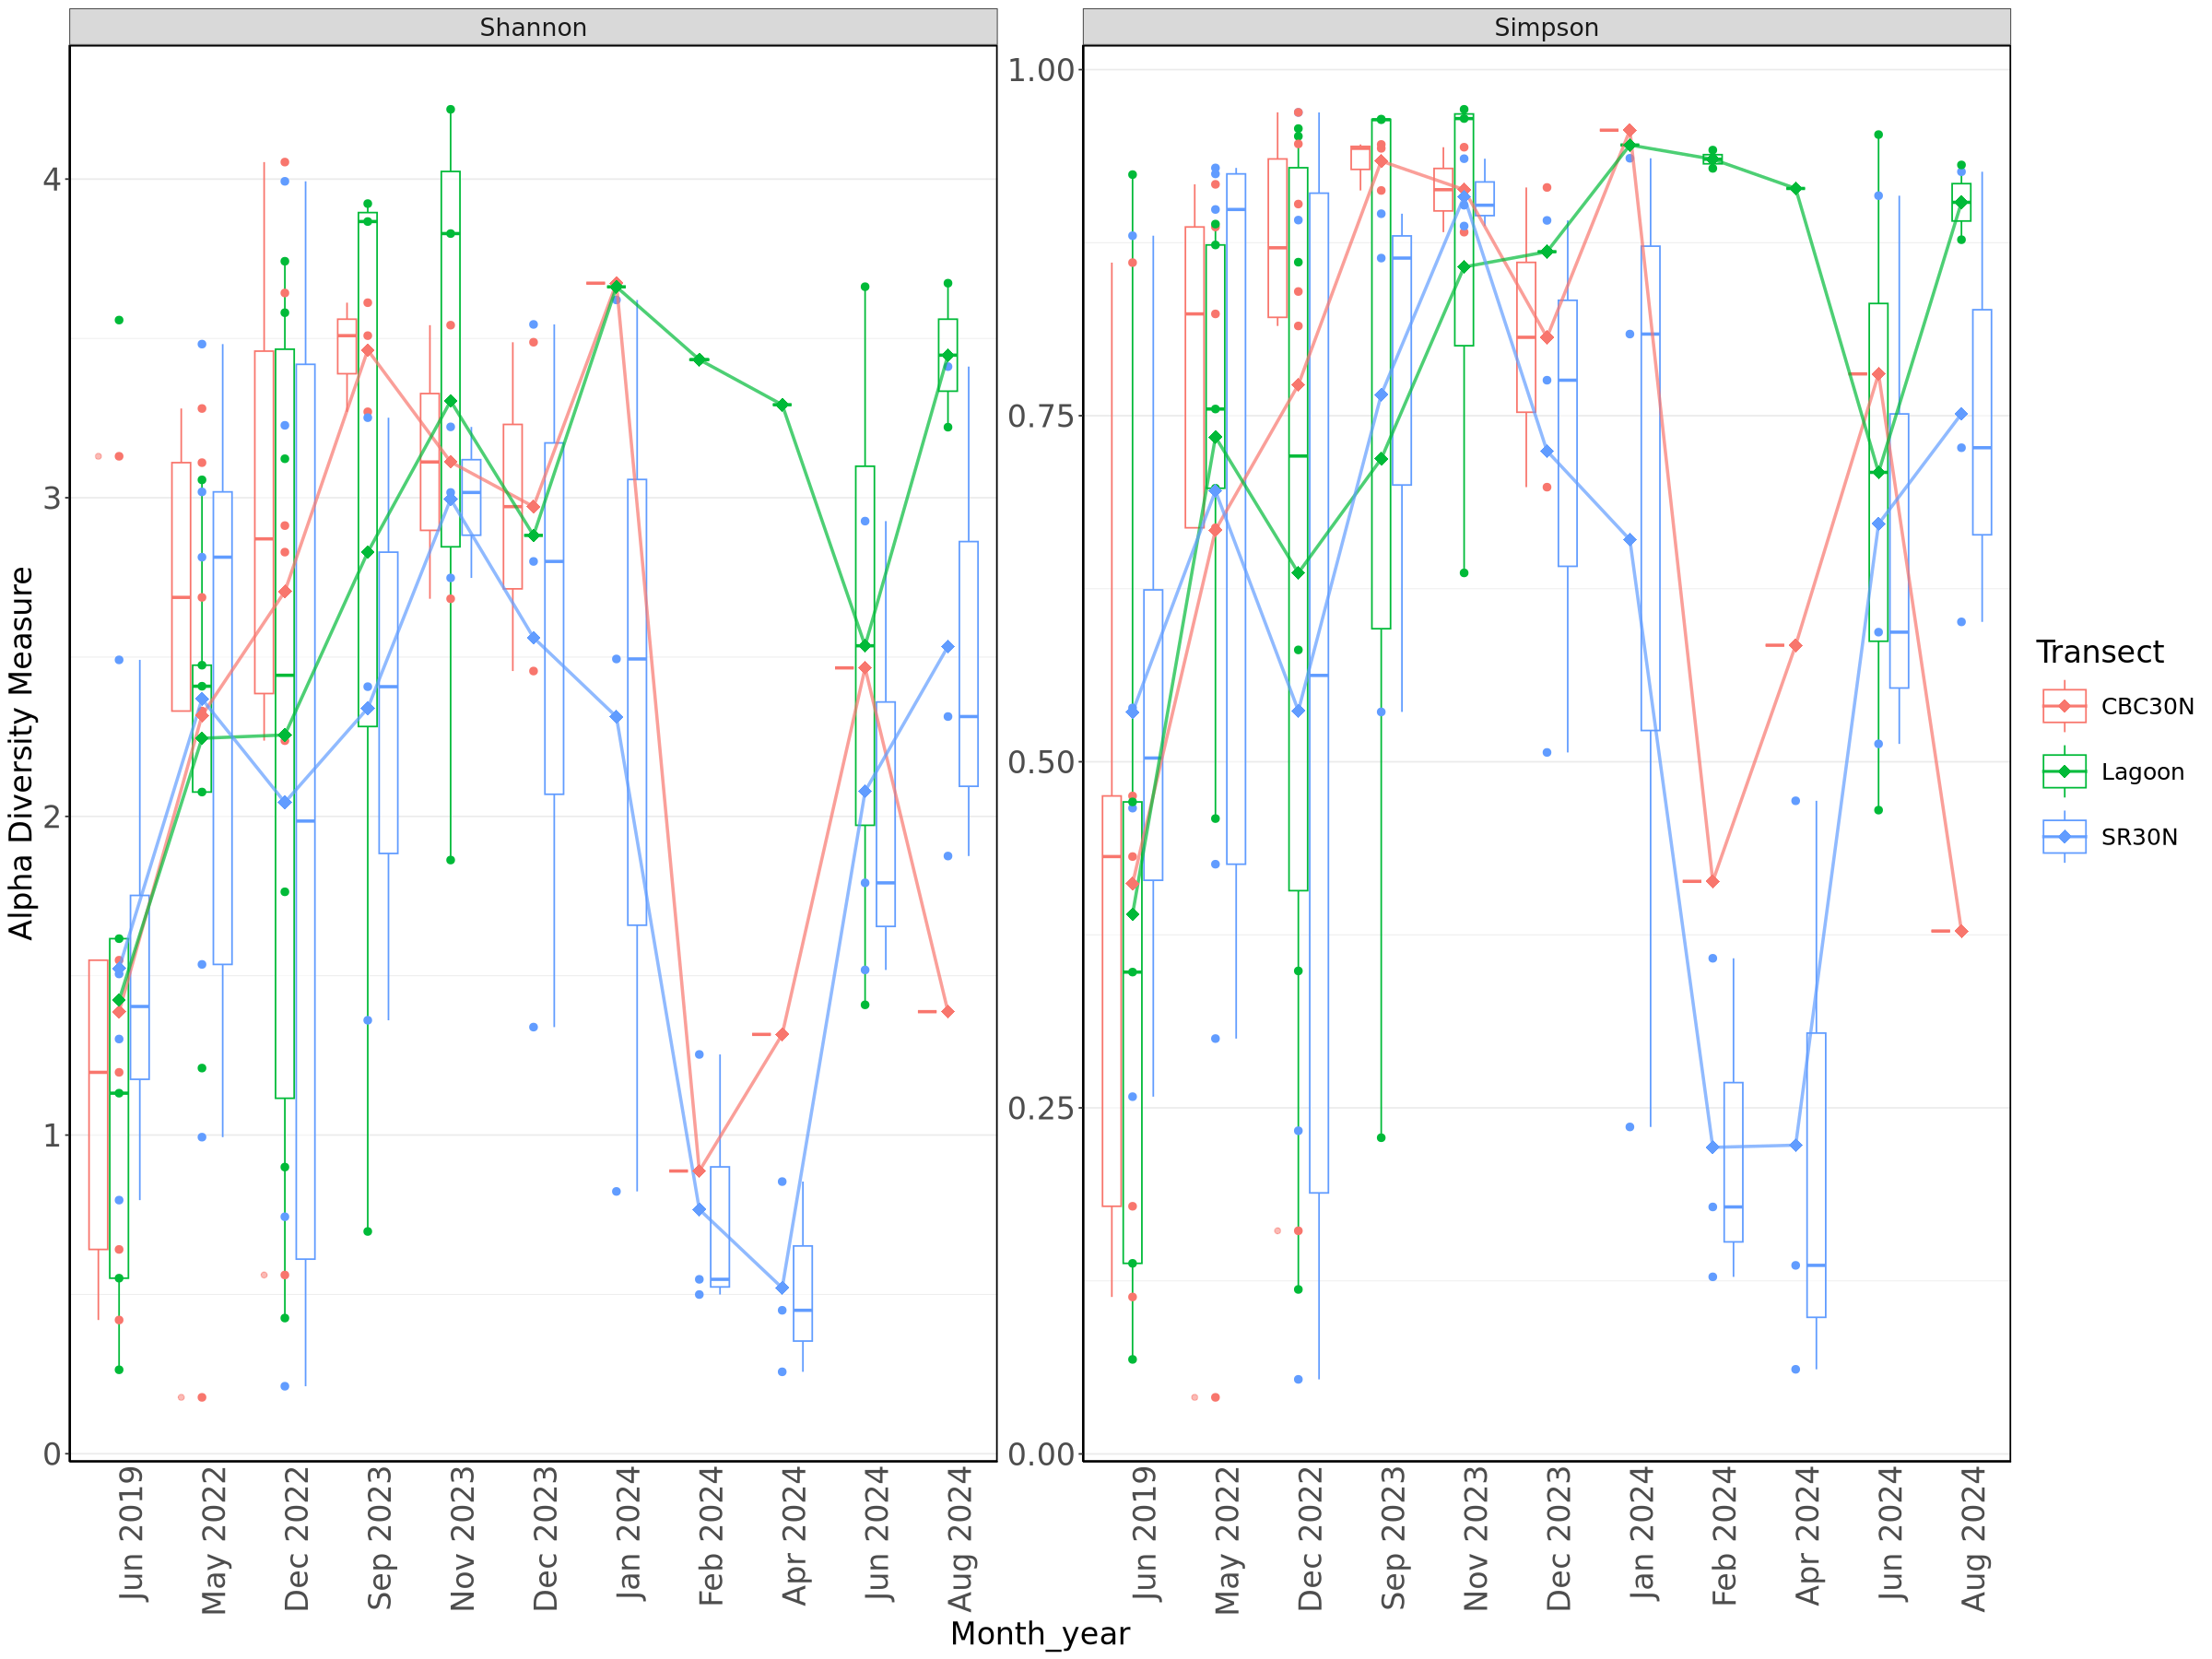

In [38]:
# Alpha diversity dot-line plot
plot_richness(ps_past, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )